# Kinetic Equilibration of Pure Water with the Atmosphere

**The situation:** a beaker of pure water is left open, in direct contact
with a large, well-mixed atmosphere (O₂, N₂, CO₂ at typical ambient
partial pressures) — no other solutes, no membrane or other barrier
between them. Equilibrium isn't instantaneous: gas has to physically
cross the gas-liquid interface, at a rate set by the volumetric
mass-transfer coefficient kLa (h⁻¹). Since CO₂ is a weak diprotic acid
(carbonic acid, laddering CO₂(aq) ⇌ HCO₃⁻ ⇌ CO₃²⁻), dissolving it shifts
pH away from neutral even with nothing else in the water — and it does so
gradually, on whatever timescale kLa sets, not all at once.

This notebook asks two questions about that process: how does pH evolve
over time at one representative kLa, and — since real gas-liquid contacting
spans a huge practical range, from a still puddle to a vigorously stirred
tank — how does the time to reach equilibrium scale with kLa itself?

The atmosphere is modelled as a large but finite gas reservoir (not a
fixed boundary condition) — large enough, relative to how little gas the
water actually needs to saturate, that its own composition barely moves
over the run (checked directly in Section 2); a "pseudo-unlimited" source
in practice, without needing a literal infinite reservoir.

In [1]:
import sys
from pathlib import Path
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt

def _find_repo():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("Run from inside the PyOMES repo")

sys.path.insert(0, str(_find_repo() / "models"))

from PyOMES.chemistry.common_species import H2O, H_plus, OH_minus, CO2, HCO3_minus, CO3_2minus
from PyOMES.chemistry import HenryEquilibrium
from PyOMES.reactions import EquilibriumReaction, ReactionSystem, StoichiometryEntry
from PyOMES.core import (
    ControlVolume, GasPhase, LiquidPhase, KineticTransferModel, Simulation,
    SimultaneousAdaptiveSolver,
)
from PyOMES.core.phases import R_L_ATM_MOL_K

# Pure water's tracked H/OH totals are tiny (~1e-8 mol, just the
# autoionization ions -- bulk solvent water isn't part of the element
# balance), so the conservation monitor's *relative* drift threshold trips
# on ordinary explicit-Euler step-to-step floating-point noise. Silenced
# only so the run cells' output stays readable; final pH/CO2(aq) values
# are unaffected.
from PyOMES.monitoring.accuracy import AccuracyWarning
from PyOMES.monitoring.conservation import ConservationWarning
warnings.filterwarnings("ignore", category=AccuracyWarning)
warnings.filterwarnings("ignore", category=ConservationWarning)

def _e(sp, coeff, phase="liquid"):
    return StoichiometryEntry(species=sp, phase=phase, coefficient=coeff)

print("Imports OK")


Imports OK


## 1  Declare the chemistry

Just water's own autoionization plus the two-step carbonate ladder — no
buffer salts, since the liquid starts as pure water:

| Reaction | log K | p$K_a$ | Role |
|---|---|---|---|
| H₂O ⇌ H⁺ + OH⁻ | −14.0 | 14.0 | water autoionization |
| CO₂(aq) + H₂O ⇌ HCO₃⁻ + H⁺ | −6.35 | 6.35 | carbonate, 1st step |
| HCO₃⁻ ⇌ CO₃²⁻ + H⁺ | −10.33 | 10.33 | carbonate, 2nd step |

O₂ and N₂ get no acid-base reaction (this notebook doesn't model
redox/respiration) — they still cross the gas-liquid interface at the
same kLa as CO₂ (Section 2), they just take no part in any reaction, so
they never show up in the pH.

Each gas also gets a Henry's-law solubility constant (Sander convention:
mol m⁻³ Pa⁻¹, plus a van 't Hoff temperature sensitivity `dlnH`), which
is what `KineticTransferModel` (Section 2) uses to know the equilibrium
*target* each gas's kinetic transfer is relaxing toward:

| Gas | H_ref (mol m⁻³ Pa⁻¹) | dlnH (K) | k_H at 25 °C (mol L⁻¹ atm⁻¹) |
|---|---|---|---|
| CO₂ | 3.4 × 10⁻⁴ | 2400 | 0.0345 |
| O₂  | 1.3 × 10⁻⁵ | 1500 | 0.00132 |
| N₂  | 6.4 × 10⁻⁶ | 1300 | 0.000648 |

In [2]:
water = EquilibriumReaction(
    stoichiometry=[_e(H2O, -1), _e(H_plus, +1), _e(OH_minus, +1)],
    log_K=-14.0, label="water",
)
co2_first = EquilibriumReaction(
    stoichiometry=[_e(CO2, -1), _e(H2O, -1), _e(HCO3_minus, +1), _e(H_plus, +1)],
    log_K=-6.35, total_id="CO2", label="co2_first",
)
co2_second = EquilibriumReaction(
    stoichiometry=[_e(HCO3_minus, -1), _e(CO3_2minus, +1), _e(H_plus, +1)],
    log_K=-10.33, total_id="CO2", label="co2_second",
)
system = ReactionSystem([water, co2_first, co2_second], label="pure_water_co2_kinetics")

co2_henry = HenryEquilibrium(H_ref=3.4e-4, dlnH=2400.0, label="henry_CO2")
o2_henry = HenryEquilibrium(H_ref=1.3e-5, dlnH=1500.0, label="henry_O2")
n2_henry = HenryEquilibrium(H_ref=6.4e-6, dlnH=1300.0, label="henry_N2")

def kH_mol_L_atm(H_ref, dlnH, T_K, T_ref=298.15):
    return (H_ref / 1000.0) * 101325.0 * math.exp(dlnH * (1.0 / T_K - 1.0 / T_ref))

print("3 equilibrium reactions declared, 3 Henry constants declared.")


3 equilibrium reactions declared, 3 Henry constants declared.


## 2  Pure water in direct contact with a large atmosphere

Liquid: 100 mL of pure water, no dissolved gas yet (`CO2=O2=N2=0.0`).
Gas: today's atmosphere (400 ppm CO₂, 20.9% O₂, 78.1% N₂) at 1 atm,
filling a 1000 L headspace — a "pseudo-unlimited" reservoir in the sense
that matters here, not literally infinite: the check below confirms the
gas phase holds several orders of magnitude more of each species than the
100 mL of water could ever draw down, so its own composition stays
essentially fixed over the whole run without needing to model an actual
infinite boundary condition.

`transfer_models=` is the only inter-phase mechanism — no membrane or
other boundary sits between the two phases, i.e. direct contact. CO₂ uses
`transfer_basis="molecular"`: the driving force acts on dissolved
molecular CO₂(aq) alone (the same convention BSM2-style gas transfer uses
for CH₄/H₂), so the effective relaxation rate is `kLa · alpha`, where
`alpha` is the CO₂(aq) fraction of total dissolved carbon. At this
system's pH (~5.6, well below pKa1 = 6.35), alpha ≈ 1 throughout, so kLa
and the effective rate are nearly the same thing. O₂/N₂ have no acid-base
ladder to speciate into, so `transfer_basis="total"` is equivalent for
them.

Sections 3-5 all integrate through `SimultaneousAdaptiveSolver(method="BDF")`
rather than the plain forward-Euler `cv.advance()` default — an implicit,
adaptive-step ODE solver (via `scipy.integrate.solve_ivp`) suited to
gas-liquid transfer coupled to pH-sensitive speciation, and the natural
choice once Section 4/5 sweep kLa across three-plus orders of magnitude
(0.1-1000 /h): a fixed explicit step size that's stable at kLa = 0.1 /h
is not guaranteed to stay stable at kLa = 1000 /h, while BDF adapts its
own internal step size to whatever the local dynamics demand.

In [3]:
V_liq = 0.1     # L (100 mL pure water)
V_gas = 1000.0  # L -- large enough not to deplete measurably; checked below
T_K = 298.15    # 25 C

p_CO2_atm, p_O2_atm, p_N2_atm = 400e-6, 0.20946, 0.78084

def build_cv(kLa, label="pure_water"):
    n_gas = (1.0 * V_gas) / (R_L_ATM_MOL_K * T_K)   # 1 atm headspace
    gas_phase = GasPhase(
        n_mol={
            "CO2": n_gas * p_CO2_atm,
            "O2": n_gas * p_O2_atm,
            "N2": n_gas * p_N2_atm,
        },
        V_L=V_gas, T_K=T_K,
    )
    liquid_phase = LiquidPhase(
        n_mol={"CO2": 0.0, "O2": 0.0, "N2": 0.0},
        V_L=V_liq, T_K=T_K,
    )
    transfer_models = {
        "CO2": KineticTransferModel(
            partition_model=co2_henry, k_transfer=kLa, transfer_basis="molecular",
        ),
        "O2": KineticTransferModel(
            partition_model=o2_henry, k_transfer=kLa, transfer_basis="total",
        ),
        "N2": KineticTransferModel(
            partition_model=n2_henry, k_transfer=kLa, transfer_basis="total",
        ),
    }
    return ControlVolume(
        phases={"gas": gas_phase, "liquid": liquid_phase},
        transfer_models=transfer_models,
        reaction_system=system,
        label=label,
    )

# Shared solver instance -- stateless (all state lives on the CV), so one
# instance is reused across every Simulation.run() call in this notebook.
bdf_solver = SimultaneousAdaptiveSolver(method="BDF")

# Depletion check: moles of each gas needed to fully saturate 100 mL of
# water at Henry's-law equilibrium, vs. moles actually available in the
# 1000 L headspace.
_kH = {"CO2": kH_mol_L_atm(co2_henry.H_ref, co2_henry.dlnH, T_K),
       "O2": kH_mol_L_atm(o2_henry.H_ref, o2_henry.dlnH, T_K),
       "N2": kH_mol_L_atm(n2_henry.H_ref, n2_henry.dlnH, T_K)}
_p = {"CO2": p_CO2_atm, "O2": p_O2_atm, "N2": p_N2_atm}
_n_gas_total = (1.0 * V_gas) / (R_L_ATM_MOL_K * T_K)
for _sp in ("CO2", "O2", "N2"):
    _needed = _kH[_sp] * _p[_sp] * V_liq
    _available = _n_gas_total * _p[_sp]
    print(f"{_sp}: needs {_needed:.3e} mol to saturate liquid, "
          f"headspace holds {_available:.3e} mol "
          f"({100*_needed/_available:.4f}% depletion at full saturation)")


CO2: needs 1.378e-06 mol to saturate liquid, headspace holds 1.635e-02 mol (0.0084% depletion at full saturation)
O2: needs 2.759e-05 mol to saturate liquid, headspace holds 8.561e+00 mol (0.0003% depletion at full saturation)
N2: needs 5.064e-05 mol to saturate liquid, headspace holds 3.192e+01 mol (0.0002% depletion at full saturation)


## 3  pH over time at kLa = 96 /h

96 /h sits in the middle of the range reported for actively agitated
gas-liquid contacting (shaken plates, stirred tanks) — fast enough that
the run window only needs to span minutes, not hours. `tau_h` is sized
to comfortably clear the expected relaxation time (`ln(20)/kLa`, the
first-order estimate for reaching 95% of equilibrium) with margin to
spare.

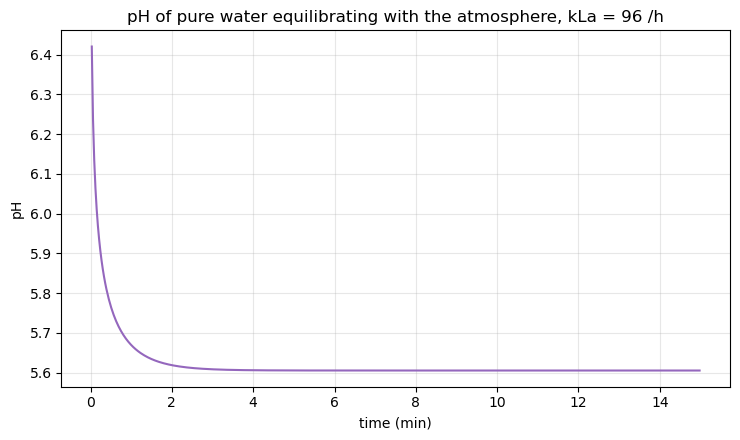

pH: 7.0000 (pure water) -> 5.6050 (equilibrated)
CO2(aq): 0 -> 13.7788 umol/L over 15.0 min (500 steps)
(textbook reference: unpolluted rainwater is ~pH 5.6, from atmospheric CO2 alone)


In [4]:
kLa_headline = 96.0   # /h

tau_h = 8.0 * math.log(20.0) / kLa_headline   # minutes-scale window, ample margin
n_steps = 500

cv = build_cv(kLa=kLa_headline, label="pure_water_headline")
result = Simulation(cvs={"main": cv}, label="usecase02b", solver=bdf_solver).run(
    tau_h=tau_h, n_steps=n_steps,
)

t_h = result.t_h
pH = result.pH["main"]
CO2_liq = result.liquid_mol["main"]["CO2"] / V_liq

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(t_h[1:] * 60.0, pH[1:], color="tab:purple")
ax.set_xlabel("time (min)")
ax.set_ylabel("pH")
ax.set_title(f"pH of pure water equilibrating with the atmosphere, kLa = {kLa_headline:.0f} /h")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"pH: {pH[0]:.4f} (pure water) -> {pH[-1]:.4f} (equilibrated)")
print(f"CO2(aq): 0 -> {CO2_liq[-1]*1e6:.4f} umol/L over {tau_h*60:.1f} min "
      f"({n_steps} steps)")
print("(textbook reference: unpolluted rainwater is ~pH 5.6, from atmospheric CO2 alone)")


## 4  How kLa sets the time to reach equilibrium

The molecular-basis driving force means dissolved CO₂(aq) relaxes toward
exactly `kH × p_CO2` (Henry's law) at equilibrium, independent of kLa —
kLa only controls *how fast* it gets there, not where it ends up (the
same logic Section 3 relied on). Sweeping kLa over three-plus orders of
magnitude — from a still, unagitated surface up past vigorous mixing —
and recording the time each run takes to reach 95% of that Henry's-law
target (`t95`, found by interpolating each run's own CO₂(aq) trajectory)
maps out that relationship directly. Each run's own `tau_h` is sized
relative to its kLa so every sweep point gets adequate resolution without
wasting steps on runs that finish in seconds.

For a system where kLa is the only physics setting the timescale (alpha
≈ 1 here, Section 2), t95 should follow the simple first-order estimate
`ln(20)/kLa` closely — plotted alongside as a dashed reference.

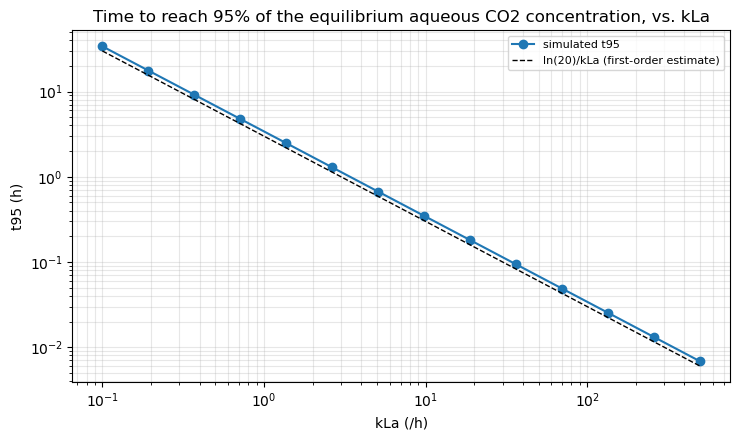

  kLa (/h)     t95 (h)   t95 (min)
      0.10     33.9413     2036.48
      0.19     17.6407     1058.44
      0.37      9.1711      550.26
      0.71      4.7693      286.16
      1.37      2.4791      148.75
      2.65      1.2875       77.25
      5.10      0.6687       40.12
      9.81      0.3473       20.84
     18.89      0.1804       10.82
     36.38      0.0937        5.62
     70.04      0.0487        2.92
    134.86      0.0253        1.52
    259.68      0.0131        0.79
    500.00      0.0068        0.41


In [5]:
kH_CO2 = kH_mol_L_atm(co2_henry.H_ref, co2_henry.dlnH, T_K)
CO2_eq = kH_CO2 * p_CO2_atm   # Henry's-law equilibrium target, independent of kLa

kLa_sweep = np.logspace(-1, np.log10(1000.0), 14)   # 0.1 - 1000 /h
t95_sweep = np.empty_like(kLa_sweep)

for i, kLa_i in enumerate(kLa_sweep):
    tau_h_i = 8.0 * math.log(20.0) / kLa_i   # margin scaled to this run's own timescale
    cv_i = build_cv(kLa=kLa_i, label=f"sweep_{i}")
    res_i = Simulation(cvs={"main": cv_i}, label=f"usecase02b_sweep_{i}", solver=bdf_solver).run(
        tau_h=tau_h_i, n_steps=500,
    )
    CO2_i = res_i.liquid_mol["main"]["CO2"] / V_liq
    t95_sweep[i] = np.interp(0.95 * CO2_eq, CO2_i, res_i.t_h)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(kLa_sweep, t95_sweep, "o-", color="tab:blue", label="simulated t95")
ax.plot(kLa_sweep, np.log(20.0) / kLa_sweep, "k--", lw=1,
        label="ln(20)/kLa (first-order estimate)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("kLa (/h)")
ax.set_ylabel("t95 (h)")
ax.set_title("Time to reach 95% of the equilibrium aqueous CO2 concentration, vs. kLa")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'kLa (/h)':>10}{'t95 (h)':>12}{'t95 (min)':>12}")
for kLa_i, t95_i in zip(kLa_sweep, t95_sweep):
    print(f"{kLa_i:>10.2f}{t95_i:>12.4f}{t95_i*60:>12.2f}")


## 5  Computation time per simulated hour vs. kLa, N=500 replicates

A separate question from Section 4's *simulated* time-to-equilibrium:
how much *wall-clock* time does `SimultaneousAdaptiveSolver(method="BDF")`
itself spend, at low, medium, and high kLa? Each of the three kLa values
below (0.1, 10, 1000 /h — spanning the same static-to-vigorous range as
Section 4) is run for the same fixed 1-hour simulated window, as a
**single** `n_steps=1` macro step — letting `solve_ivp`'s own adaptive
internal stepping do all the work, rather than forcing it through many
Python-level macro-step calls, so the timing reflects the solver's own
cost per simulated experimental hour rather than Python call overhead.

As in the timing sections elsewhere in this repo, each kLa gets one
untimed warmup call first (so neither's first-call import/setup cost
biases the result), then mean ± standard deviation over 500 timed
replicate calls — spread across replicates, not a single best-of-N
figure, since the point is to characterize each kLa's own cost
distribution.

In [ ]:
import time

N_REPS = 500
tau_h_timing = 1.0   # one simulated experimental hour
kLa_timing_values = [0.1, 10.0, 1000.0]

def time_replicates(fn, n=N_REPS):
    fn()  # untimed warmup -- first call pays one-time import/setup costs
    times_s = np.empty(n)
    for i in range(n):
        t0 = time.perf_counter()
        fn()
        times_s[i] = time.perf_counter() - t0
    return times_s * 1e3  # ms

def _run_one_experimental_hour(kLa_i):
    cv_i = build_cv(kLa=kLa_i, label="timing")
    Simulation(cvs={"main": cv_i}, label="usecase02b_timing", solver=bdf_solver).run(
        tau_h=tau_h_timing, n_steps=1,
    )

timing_results = {
    f"kLa = {kLa_i:g} /h": time_replicates(lambda kLa_i=kLa_i: _run_one_experimental_hour(kLa_i))
    for kLa_i in kLa_timing_values
}

print(f"{'kLa':<14}{'mean (ms/h)':>14}{'std (ms/h)':>14}")
for label_i, times_ms in timing_results.items():
    print(f"{label_i:<14}{times_ms.mean():>14.4f}{times_ms.std():>14.4f}")
